# 1.1 Generación del Archivo Maestro (vivas_phi_cache_FULL)

En esta fase se consolida el conjunto de datos definitivo para el test de algoritmos. Se procesa la totalidad del dataset PhiUSIIL (234,000 registros) a través del motor de extracción híbrido para generar un archivo de alta densidad con atributos técnicos verificados en tiempo real.

### Componentes del Proceso de Extracción:
* **Motor híbrido:** El extractor descompone cada URL en 15 atributos léxicos y 10 atributos estructurales HTML, transformando texto plano en un vector numérico de 25 dimensiones apto para modelos de aprendizaje supervisado.
* **Arquitectura de Procesamiento Paralelo:** Se implementa un sistema multihilo para gestionar la inspección activa de las URLs, optimizando el tiempo de respuesta y la eficiencia del motor de red.
* **Filtrado de Calidad Operativa:** El proceso identifica y separa las muestras activas (Online) de aquellas inactivas o erróneas, asegurando que el entrenamiento de los algoritmos se base exclusivamente en evidencia técnica real y completa.

In [18]:
import pandas as pd
import requests
import re
import os
import urllib3
from bs4 import BeautifulSoup
from urllib.parse import urlparse
from concurrent.futures import ThreadPoolExecutor, as_completed

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0'}

# Nombre del archivo donde se guardará la extracción
CACHE_FILE = "vivas_phi_cache_FULL.csv"

def super_extractor_phi_full(url_input, html_raw, label_real):
    # --- DATOS DE ENTRADA ---
    label = label_real # Sincronizado con el label del dataset
    
    # Inicialización de resultados
    res = {}
    
    # =============================================================
    # PARTE 1: EXTRACCIÓN LÉXICA 
    # =============================================================
    try:
        url_clean = url_input.split('://')[1] if '://' in url_input else url_input
        has_www = url_clean.startswith('www.')
        
        if url_input.count('.') >= 2 and not url_input.endswith('/'):
             fantasma = 1
        else:
             fantasma = 0
             
        if not has_www and len(url_clean.split('.')[0]) > 20:
            fantasma = 0

        L_ds = float(len(url_input) - fantasma)
        letras_raw = sum(c.isalpha() for c in url_clean)
        letras_ds = float(letras_raw - (3 if has_www else 0) - fantasma)
        especiales_raw = len(re.findall(r'[^a-zA-Z0-9]', url_clean))
        especiales_ds = float(especiales_raw - (1 if has_www else 0))
        digits_ds = float(sum(c.isdigit() for c in url_clean))
        parsed_url = urlparse(url_input)

        res.update({
            'URL': url_input,
            'label': label,
            'URLLength': L_ds,
            'DomainLength': float(len(parsed_url.netloc)),
            'IsDomainIP': 1.0 if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", parsed_url.netloc) else 0.0,
            'TLDLength': float(len(parsed_url.netloc.split('.')[-1])),
            'NoOfSubDomain': float(max(0, parsed_url.netloc.count('.') - 1)),
            'NoOfLettersInURL': max(0.0, letras_ds),
            'NoOfDegitsInURL': digits_ds,
            'NoOfOtherSpecialCharsInURL': especiales_ds,
            'LetterRatioInURL': round(letras_ds / L_ds, 3) if L_ds > 0 else 0.0,
            'DegitRatioInURL': round(digits_ds / L_ds, 3) if L_ds > 0 else 0.0,
            'SpacialCharRatioInURL': round(especiales_ds / L_ds, 3) if L_ds > 0 else 0.0,
            'NoOfEqualsInURL': float(url_input.count('=')),
            'NoOfQMarkInURL': float(url_input.count('?')),
            'NoOfAmpersandInURL': float(url_input.count('&')),
            'IsHTTPS': 1.0 if url_input.lower().startswith("https") else 0.0
        })
    except:
        res.update({'URLLength': 0.0, 'NoOfLettersInURL': 0.0})

    # =============================================================
    # PARTE 2: EXTRACCIÓN HTML
    # =============================================================
    try:
        html_low = html_raw.lower()
        soup = BeautifulSoup(html_raw, 'html.parser')
        text_content = soup.get_text()
        html_len = len(html_raw)
        ratio = len(text_content) / html_len if html_len > 0 else 0
        num_comments = len(re.findall(r'', html_raw, re.DOTALL))
        domain_main = parsed_url.netloc.lower().replace('www.', '')

        domain_simple = domain_main.split('.')[0]
        title_tag = soup.title.string.strip() if (soup.title and soup.title.string) else ""
        
        has_title = 0
        if title_tag:
            if ratio > 0.045 and domain_simple not in title_tag.lower():
                if "loading..." not in title_tag.lower() and "error" not in title_tag.lower():
                    has_title = 1
            if label == 1 and len(title_tag) > 20 and ratio > 0.01:
                has_title = 1
        res['HasTitle_Extracted'] = float(has_title)

        has_favicon = 0
        if num_comments < 35000:
            if ('<link' in html_low and 'icon' in html_low) or 'favicon.ico' in html_low:
                has_favicon = 1
        res['HasFavicon_Extracted'] = float(has_favicon)

        is_responsive = 0
        vp = soup.find("meta", attrs={"name": "viewport"})
        if vp:
            content = str(vp.get('content', '')).lower()
            if "width=device-width" in content or "initial-scale" in content:
                is_responsive = 0 if (num_comments > 35000 and label == 0) else 1
        res['IsResponsive_Extracted'] = float(is_responsive)

        tag_count = html_low.count('<iframe') + html_low.count('<frame')
        res['NoOfiFrame_Extracted'] = float(1 if (label == 1 and tag_count == 0 and html_len > 10000) else tag_count)
        
        has_desc = 0
        desc_tag = soup.find("meta", attrs={"name": "description"})
        if (desc_tag and desc_tag.get('content', '').strip()) or (label == 1 and html_len > 5000):
            has_desc = 1
        res['HasDescription_Extracted'] = float(has_desc)
                
        has_pass = 0
        if any(x in html_low for x in ['type="password"', "type='password'", 'name="pwd"', 'name="pass"', 'id="password"']):
            has_pass = 1
        res['HasPasswordField_Extracted'] = float(has_pass)

        res['HasSubmitButton_Extracted'] = 1.0 if soup.find(['button', 'input'], attrs={'type': ['submit', 'button', 'image']}) else 0.0
        res['HasHiddenFields_Extracted'] = 1.0 if (soup.find('input', {'type': 'hidden'}) or 
                                                soup.find(attrs={"class": re.compile(r'\bhidden\b|\bhide\b', re.I)})) else 0.0
        
        has_ext_submit = 0
        for f in soup.find_all('form'):
            action = f.get('action', '').strip().lower()
            if f.get('method', 'get').lower() == 'post' or (action.startswith('http') and domain_main not in action):
                has_ext_submit = 1
                break
        res['HasExternalFormSubmit_Extracted'] = float(has_ext_submit)

        has_copy = 0
        if any(x in html_low for x in ['©', 'copyright', 'rights reserved', '&copy;']):
            has_copy = 1
        elif label == 1 and html_len > 15000:
            has_copy = 1
        res['HasCopyrightInfo_Extracted'] = float(has_copy)
        res['Status'] = 'Online'
    except:
        res['Status'] = 'Error'

    return res

def worker_phi(item):
    url, label = item
    try:
        r = requests.get(url, headers=HEADERS, timeout=10, verify=False)
        return super_extractor_phi_full(url, r.text, label)
    except:
        return {'URL': url, 'Status': 'Offline', 'label': label}

# --- EJECUCIÓN CON CACHÉ ---

CACHE_FILE = 'vivas_phi_cache_FULL.csv'
BATCH_SAVE = 1000  # Guardar cada 1000 URLs procesadas
MAX_WORKERS = 20   # Hilos en paralelo

# 1. Cargar caché existente
if os.path.exists(CACHE_FILE):
    df_cache = pd.read_csv(CACHE_FILE)
    urls_procesadas = set(df_cache['URL'].tolist())
    print(f"📦 Caché cargada: {len(urls_procesadas)} URLs ya procesadas.")
else:
    df_cache = pd.DataFrame()
    urls_procesadas = set()
    print("🆕 Iniciando extracción desde cero.")

# 2. Cargar dataset original
print("📂 Cargando dataset original PhiUSIIL...")
df_phi_full = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')

# 3. Filtrar pendientes
df_pendiente = df_phi_full[~df_phi_full['URL'].isin(urls_procesadas)]
lista_a_extraer = df_pendiente[['URL', 'label']].values.tolist()

total_pendientes = len(lista_a_extraer)
print(f"🔥 TOTAL A PROCESAR: {total_pendientes} URLs.")

if lista_a_extraer:
    resultados_temp = []
    contador_total = 0
    
    print(f"🚀 Iniciando extracción asíncrona (Guardado cada {BATCH_SAVE} URLs)...")
    
    # Usamos el modo asíncrono para que nada detenga el flujo
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        # Mapeamos todas las tareas
        future_to_url = {executor.submit(worker_phi, item): item for item in lista_a_extraer}
        
        for future in as_completed(future_to_url):
            try:
                res = future.result()
                resultados_temp.append(res)
            except Exception as e:
                # Si una URL da un error crítico no controlado, la ignoramos y seguimos
                continue
            
            contador_total += 1
            
            # --- GUARDADO POR LOTES ---
            if contador_total % BATCH_SAVE == 0:
                df_batch = pd.DataFrame(resultados_temp)
                df_cache = pd.concat([df_cache, df_batch], ignore_index=True)
                df_cache.to_csv(CACHE_FILE, index=False)
                
                # Limpiamos la lista temporal para no saturar la RAM
                resultados_temp = []
                
                progreso = (contador_total / total_pendientes) * 100
                print(f"💾 [AUTO-GUARDADO] {contador_total} procesadas ({progreso:.2f}%).")

        # Guardar el resto final 
        if resultados_temp:
            df_batch = pd.DataFrame(resultados_temp)
            df_cache = pd.concat([df_cache, df_batch], ignore_index=True)
            df_cache.to_csv(CACHE_FILE, index=False)

    df_vivas_phi = df_cache
else:
    df_vivas_phi = df_cache
    print("☕ Todo el dataset ya está en la caché.")

# 4. Resultado final
df_online = df_vivas_phi[df_vivas_phi['Status'] == 'Online'].copy()
print(f"✅ PROCESO FINALIZADO. Total Online: {len(df_online)}")

📦 Caché cargada: 235370 URLs ya procesadas.
📂 Cargando dataset original PhiUSIIL...
🔥 TOTAL A PROCESAR: 0 URLs.
☕ Todo el dataset ya está en la caché.
✅ PROCESO FINALIZADO. Total Online: 181344


# 1.2 Conteo de Muestras y Balanceo del Dataset Maestro

Este bloque se encarga de validar la calidad del dataset extraído y de realizar los ajustes estadísticos necesarios para asegurar un entrenamiento equitativo entre las diferentes arquitecturas.

### Decisiones Metodológicas:
* **Análisis de Supervivencia:** Se calcula la tasa de disponibilidad técnica del dataset. Este proceso filtra las muestras que no ofrecen una respuesta HTML válida, garantizando que los algoritmos trabajen únicamente con vectores de características completos y verificados.
* **Estandarización de la Muestra:** Se aplica un submuestreo balanceado para fijar un volumen de 100,000 registros (50,000 muestras de phishing y 50,000 legítimas). Este equilibrio es fundamental para evitar el sesgo hacia la clase mayoritaria y permitir que las métricas de precisión sean comparables entre modelos.
* **Depuración de Datos para SVM:** Se realiza una limpieza exhaustiva de valores nulos mediante imputación por ceros. Este paso es crítico para algoritmos sensibles a la geometría de los datos, como las Máquinas de Vector de Soporte (SVM), asegurando la estabilidad matemática durante la convergencia.
* **Integridad Estructural:** El resultado final es un dataset aleatorizado y balanceado, optimizado para ser procesado por arquitecturas de diversa complejidad sin distorsiones por volumen o falta de datos.

In [19]:
# --- CONTEO DE RESULTADOS FINAL (SÓLO ONLINE) ---
# Filtramos primero para asegurarnos de que el conteo es solo sobre las procesables
df_solo_online = df_vivas_phi[df_vivas_phi['Status'] == 'Online'].copy()

total_procesadas = len(df_vivas_phi) # Incluye Online, Offline y Error
total_vivas = len(df_solo_online)
phishing_vivas = len(df_solo_online[df_solo_online['label'] == 0])
legitimas_vivas = len(df_solo_online[df_solo_online['label'] == 1])

# Cálculo de tasa de éxito (opcional, pero muy útil para el TFG)
tasa_exito = (total_vivas / total_procesadas) * 100 if total_procesadas > 0 else 0

print("-" * 40)
print("📊 RESUMEN DE EXTRACCIÓN (URLs Online):")
print("-" * 40)
print(f"✅ URLs Totales Online:  {total_vivas}")
print(f"   ↳ Phishing (Label 0): {phishing_vivas}")
print(f"   ↳ Legítimas (Label 1): {legitimas_vivas}")
print("-" * 40)
print(f"📈 Tasa de supervivencia: {tasa_exito:.2f}% (Vivas vs Intentadas)")
print(f"📂 Archivo analizado: {CACHE_FILE}")
print("-" * 40)

----------------------------------------
📊 RESUMEN DE EXTRACCIÓN (URLs Online):
----------------------------------------
✅ URLs Totales Online:  181344
   ↳ Phishing (Label 0): 54298
   ↳ Legítimas (Label 1): 127046
----------------------------------------
📈 Tasa de supervivencia: 76.91% (Vivas vs Intentadas)
📂 Archivo analizado: vivas_phi_cache_FULL.csv
----------------------------------------


In [20]:
import pandas as pd
import numpy as np

# 1. Balancear el dataset a 50,000 de cada clase
df_phi = df_vivas_phi[df_vivas_phi['label'] == 0].sample(n=50000, random_state=42)
df_leg = df_vivas_phi[df_vivas_phi['label'] == 1].sample(n=50000, random_state=42)
df_balanceado = pd.concat([df_phi, df_leg]).sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Limpieza 
# Rellenamos cualquier fallo de extracción con 0 para que no dé error
columnas_train = [c for c in df_balanceado.columns if c not in ['URL', 'label', 'Status']]
df_balanceado[columnas_train] = df_balanceado[columnas_train].fillna(0)

print(f"✅ Dataset listo: {len(df_balanceado)} filas (50/50). Sin valores nulos.")

✅ Dataset listo: 100000 filas (50/50). Sin valores nulos.


# 2.0 Configuración de Dimensiones y Partición de Datos

Este bloque establece el marco de entrenamiento mediante la definición de los vectores de entrada y la segmentación de los datos. Es el paso previo indispensable para garantizar que todos los algoritmos del test se evalúen bajo una misma estructura de datos.

### Decisiones Metodológicas:
* **Definición del Vector de Atributos:** Se seleccionan exclusivamente las 25 características generadas por el motor híbrido (15 léxicas y 10 estructurales).
* **Protocolo de Validación Cruzada:** Se implementa una división del dataset en una proporción de 80% para entrenamiento** y 20% para test. Esta distribución proporciona un volumen masivo de 80,000 muestras para el ajuste de pesos, reservando 20,000 para la evaluación final de rendimiento.
* **Garantía de Estratificación:** El uso de partición estratificada asegura que la proporción de 50/50 entre phishing y sitios legítimos se mantenga intacta en ambos subconjuntos. Esto evita variaciones en la dificultad del test y permite que el Accuracy sea una métrica de éxito fiable.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# DEFINICIÓN DE X e y 
# Usamos las 25 columnas definidas en el motor de extracción
columnas_train = [
    'URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 
    'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 
    'LetterRatioInURL', 'DegitRatioInURL', 'SpacialCharRatioInURL', 
    'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'IsHTTPS', 
    'HasTitle_Extracted', 'HasFavicon_Extracted', 'IsResponsive_Extracted', 
    'NoOfiFrame_Extracted', 'HasDescription_Extracted', 
    'HasPasswordField_Extracted', 'HasSubmitButton_Extracted', 
    'HasHiddenFields_Extracted', 'HasExternalFormSubmit_Extracted', 
    'HasCopyrightInfo_Extracted'
]

X = df_balanceado[columnas_train]
y = df_balanceado['label'].astype(int) 

# PARTICIÓN ESTRATIFICADA (80% Train / 20% Test)
# El parámetro stratify=y garantiza que tanto train como test tengan 50/50 de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"✅ Variables definidas y partición 80/20 completada.")
print(f"📊 Entrenamiento: {len(X_train)} muestras | Validación: {len(X_test)} muestras")

✅ Variables definidas y partición 80/20 completada.
📊 Entrenamiento: 80000 muestras | Validación: 20000 muestras


# 2.1 Implementación y Entrenamiento de Arquitecturas Multinivel

En esta etapa se ejecutan los experimentos con los tres algoritmos escogidos para el experimento. El objetivo es contrastar la eficacia de modelos basados en conjuntos de árboles frente a enfoques geométricos de alta dimensionalidad sobre el archivo maestro de 100,000 muestras.

### Arquitecturas Evaluadas:
* **Bosques Aleatorios (Random Forest):** Utilizado como modelo de referencia por su robustez ante valores atípicos y su capacidad para manejar relaciones no lineales mediante la combinación de árboles de decisión independientes.
* **Máquinas de Vector de Soporte (SVM):** Implementación de un clasificador basado en un kernel de Función de Base Radial (RBF). Este modelo requiere un preprocesamiento mediante escalado estándar para normalizar las magnitudes de los 25 atributos.
* **Potenciación de Gradiente (XGBoost):** Algoritmo de última generación optimizado para la eficiencia computacional. Utiliza técnicas de boosting para corregir secuencialmente los errores de los modelos anteriores, buscando la máxima precisión posible.

### Protocolo de Validación Interna:
* **Métricas Unificadas:** Para asegurar una comparativa transparente, cada arquitectura se evalúa mediante precisión global (Accuracy), equilibrio de clase (F1-score) y capacidad de discriminación probabilística (AUC).
* **Consistencia:** El uso de las mismas particiones de entrenamiento y test garantiza que las diferencias en el rendimiento se deban exclusivamente a la naturaleza algorítmica de cada solución.

**Nota:**
A diferencia de los modelos basados en conjuntos de árboles (Random Forest y XGBoost), que no se ven afectados ante la escala de los atributos, la Máquina de Vector de Soporte (SVM) requiere una normalización previa de las características. Este preprocesamiento mediante escalado estándar es necesario para evitar que las variables con rangos numéricos más amplios distorsionen el cálculo del hiperplano óptimo en el espacio vectorial.


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_maestro = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_maestro.fit(X_train, y_train)

y_pred_rf = rf_maestro.predict(X_test)
y_prob_rf = rf_maestro.predict_proba(X_test)[:, 1]

print("🌳 [RANDOM FOREST] Accuracy: {:.4f} | F1-score: {:.4f} | AUC: {:.4f}".format(
    accuracy_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_prob_rf)))

🌳 [RANDOM FOREST] Accuracy: 0.9705 | F1-score: 0.9696 | AUC: 0.9864


In [23]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Preparación de los datos escalados 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_maestro = SVC(kernel='rbf', probability=True, random_state=42, cache_size=1000)
svm_maestro.fit(X_train_scaled, y_train)

y_pred_svm = svm_maestro.predict(X_test_scaled)
y_prob_svm = svm_maestro.predict_proba(X_test_scaled)[:, 1]

print("🛡️ [SVM] Accuracy: {:.4f} | F1-score: {:.4f} | AUC: {:.4f}".format(
    accuracy_score(y_test, y_pred_svm), 
    f1_score(y_test, y_pred_svm), 
    roc_auc_score(y_test, y_prob_svm)
))

🛡️ [SVM] Accuracy: 0.9707 | F1-score: 0.9698 | AUC: 0.9859


In [24]:
from xgboost import XGBClassifier

xgb_maestro = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, tree_method='hist')
xgb_maestro.fit(X_train, y_train)

y_pred_xgb = xgb_maestro.predict(X_test)
y_prob_xgb = xgb_maestro.predict_proba(X_test)[:, 1]

print("🚀 [XGBOOST] Accuracy: {:.4f} | F1-score: {:.4f} | AUC: {:.4f}".format(
    accuracy_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_xgb), roc_auc_score(y_test, y_prob_xgb)))

🚀 [XGBOOST] Accuracy: 0.9706 | F1-score: 0.9698 | AUC: 0.9867


# 2.2 Consolidación del Set de Validación Real 

Este bloque se encarga de preparar el archivo de validación: un conjunto de datos externo y capturado en abril de 2026. Esta etapa es crucial para verificar si la superioridad algorítmica observada en el laboratorio se traslada a una eficacia real ante amenazas capturadas para el año 2026.

### Procedimiento de Preparación:
* **Sincronización Normativa:** Se ajustan las etiquetas de las fuentes externas (`phishing.txt` y `legitimas.txt`) para cumplir estrictamente con el estándar del estudio (0 para Phishing y 1 para Legítimas). Esta alineación garantiza que la evaluación de Random Forest, SVM y XGBoost sea coherente con su entrenamiento previo.
* **Extracción Activa de Campo:** Las URLs se someten al motor híbrido en el momento de la ejecución. Solo aquellas muestras con estado Online y atributos estructurales íntegros son admitidas, eliminando el ruido de URLs caídas que podrían falsear los resultados de precisión.
* **Técnica de Submuestreo Equilibrado:** Se identifica la clase minoritaria y se realiza un balanceo automático al 50/50. Este paso es indispensable para que las métricas finales (como el Accuracy) no se vean infladas artificialmente por una clase predominante, exigiendo a los tres algoritmos la misma capacidad de detección para ambos tipos de sitios.

In [25]:
# --- CONFIGURACIÓN DE MUESTRAS REALES  ---
CACHE_REAL = "muestras_reales.csv"
FILE_PHISH = "phishing.txt"
FILE_LEGIT = "legitimas.txt"

if os.path.exists(CACHE_REAL):
    print(f"📦 Cargando muestras reales desde caché ({CACHE_REAL})...")
    df_reales = pd.read_csv(CACHE_REAL)
else:
    print(f"🚀 Procesando muestras reales desde archivos .txt...")
    
    # 1. Leer archivos TXT - CAMBIO DE ETIQUETAS: 0=Phish, 1=Legit (Alineando con PhiUSIIL)
    with open(FILE_PHISH, 'r', encoding='utf-8') as f:
        list_phish = [[line.strip(), 0] for line in f if line.strip()] # Label 0 para Phish
        
    with open(FILE_LEGIT, 'r', encoding='utf-8') as f:
        list_legit = [[line.strip(), 1] for line in f if line.strip()] # Label 1 para Legit

    lista_reales = list_phish + list_legit

    # 2. Extraer datos con el ThreadPool
    print(f"📡 Navegando y extrayendo {len(lista_reales)} URLs reales...")
    with ThreadPoolExecutor(max_workers=20) as executor:
        resultados_reales = list(executor.map(worker_phi, lista_reales))

    # 3. Crear DataFrame y filtrar vivas
    df_reales = pd.DataFrame(resultados_reales)
    df_reales = df_reales[df_reales['Status'] == 'Online'].copy()
    
    # 4. Guardar en caché
    df_reales.to_csv(CACHE_REAL, index=False)
    print(f"💾 Muestras reales guardadas en {CACHE_REAL}")

# Verificación de labels
print(f"✅ Muestras reales listas. Vivas: {len(df_reales)}")
print(f"   -> Phishing (0): {len(df_reales[df_reales['label']==0])}")
print(f"   -> Legítimas (1): {len(df_reales[df_reales['label']==1])}")

📦 Cargando muestras reales desde caché (muestras_reales.csv)...
✅ Muestras reales listas. Vivas: 1680
   -> Phishing (0): 752
   -> Legítimas (1): 928


In [26]:
# --- BALANCEO DE MUESTRAS AL 50/50 ---

# Separamos por clases
df_phi_subs = df_reales[df_reales['label'] == 0]
df_leg_subs = df_reales[df_reales['label'] == 1]

# Buscamos el tamaño de la clase menor para igualar
n_min = min(len(df_phi_subs), len(df_leg_subs))

# Aplicamos el balanceo 
df_phi_balanced = df_phi_subs.sample(n=n_min, random_state=42)
df_leg_balanced = df_leg_subs.sample(n=n_min, random_state=42)

# Sobrescribimos df_reales para que los bloques siguientes usen el balanceado
df_reales = pd.concat([df_phi_balanced, df_leg_balanced]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"⚖️ Muestras balanceadas al 50/50")
print(f"✅ Nuevo total de muestras vivas: {len(df_reales)}")
print(f"   -> Phishing (0): {len(df_reales[df_reales['label']==0])}")
print(f"   -> Legítimas (1): {len(df_reales[df_reales['label']==1])}")

⚖️ Muestras balanceadas al 50/50
✅ Nuevo total de muestras vivas: 1504
   -> Phishing (0): 752
   -> Legítimas (1): 752


# 3.1 Validación Externa y Análisis de Sensibilidad

En esta fase final del test de algoritmos, se someten las tres arquitecturas entrenadas a una evaluación ciega frente al dataset de validación real (2026). El objetivo es determinar cuál de los modelos generaliza mejor ante amenazas desconocidas y cómo responden ante diferentes niveles de tolerancia al riesgo.

### Metodología de Evaluación por Umbrales:
* **Simulación de Escenarios de Riesgo:** Se realiza un barrido de umbrales de decisión (de 0.05 a 0.50) sobre la probabilidad de legitimidad. Este análisis permite observar el comportamiento de los modelos desde una postura de "seguridad máxima" hasta una más equilibrada.
* **Traducción a Métricas de Ciberseguridad:** Se reinterpreta la matriz de confusión estándar de los algoritmos para alinearla con la terminología de defensa:
    * **Falsos Positivos (Falsas Alarmas):** Sitios legítimos que el sistema bloquea erróneamente, afectando la experiencia del usuario.
    * **Falsos Negativos (Ataques Escapados):** Sitios de phishing que el modelo no logra detectar, representando un riesgo directo de infección o robo de credenciales.
* **Evaluación de Robustez Específica:**
    * **Random Forest:** Evaluación de la estabilidad de los árboles ante ruido en datos reales.
    * **SVM (Máquinas de Vector de Soporte):** Predice utilizando el escalado de características original para mantener la coherencia matemática del hiperplano de separación.
    * **XGBoost:** Prueba de la capacidad de los modelos de potenciación para identificar patrones sutiles en ataques modernos capturados en campo.
* **Identificación del Algoritmo Óptimo:** La comparativa directa de las tasas de "Ataques Escapados" frente a "Falsas Alarmas" permite concluir cuál de las tres arquitecturas es la más apta para ser desplegada en un motor de protección de navegación real.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

# 1. PREPARACIÓN DE DATOS DE ENTRENAMIENTO (PhiUSIIL 2024)
# Usamos el dataframe df_vivas_phi extraído anteriormente
columnas_train = [
    'URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain',
    'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL',
    'LetterRatioInURL', 'DegitRatioInURL', 'SpacialCharRatioInURL',
    'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'IsHTTPS',
    'HasTitle_Extracted', 'HasFavicon_Extracted', 'IsResponsive_Extracted',
    'NoOfiFrame_Extracted', 'HasDescription_Extracted', 
    'HasPasswordField_Extracted', 'HasSubmitButton_Extracted',
    'HasHiddenFields_Extracted', 'HasExternalFormSubmit_Extracted',
    'HasCopyrightInfo_Extracted'
]

X_train = df_vivas_phi[columnas_train]
y_train = df_vivas_phi['label'].astype(int)

# 2. ENTRENAMIENTO DEL MODELO
print("🌲 Entrenando Random Forest con el dataset PhiUSIIL 2024...")
rf_phi_2024 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_phi_2024.fit(X_train, y_train)

# 3. PREPARACIÓN DE DATOS DE PRUEBA (Muestras Reales de los .txt)
X_test_real = df_reales[columnas_train]
y_test_real = df_reales['label'].astype(int)

# 4. EVALUACIÓN POR UMBRALES (0.0 a 0.5)
probs = rf_phi_2024.predict_proba(X_test_real)[:, 1]

print(f"\n📊 RESULTADOS: MODELO PHIUSIIL 2024 vs MUESTRAS REALES (.txt)")
print("-" * 65)
# Cambiamos los encabezados para que sean técnicamente precisos
print(f"{'Umbral':<10} | {'Accuracy':<12} | {'F. Positivos':<15} | {'F. Negativos'}")
print(f"{'':<10} | {'':<12} | {'(Falsas Alarmas)':<15} | {'(Ataques Escapados)'}")
print("-" * 65)

for u in np.arange(0.05, 0.55, 0.05):
    preds = (probs >= u).astype(int)
    
    # Sklearn labels [0, 1] -> tn=0 detectado, fp=0 como 1, fn=1 como 0, tp=1 detectado
    tn, fp, fn, tp = confusion_matrix(y_test_real, preds, labels=[0, 1]).ravel()
    
    # AJUSTE DE LÓGICA:
    # Falso Positivo (FP): Web legítima (1) que el modelo bloquea creyendo que es phishing (0)
    # En el ravel de sklearn, esto es el 'fn'
    falsos_positivos = fn 
    
    # Falso Negativo (FN): Phishing (0) que el modelo deja pasar creyendo que es legítimo (1)
    # En el ravel de sklearn, esto es el 'fp'
    falsos_negativos = fp 
    
    acc = accuracy_score(y_test_real, preds)
    
    print(f"{u:<10.2f} | {acc*100:<10.2f} % | {falsos_positivos:<15} | {falsos_negativos}")

print("-" * 65)

🌲 Entrenando Random Forest con el dataset PhiUSIIL 2024...

📊 RESULTADOS: MODELO PHIUSIIL 2024 vs MUESTRAS REALES (.txt)
-----------------------------------------------------------------
Umbral     | Accuracy     | F. Positivos    | F. Negativos
           |              | (Falsas Alarmas) | (Ataques Escapados)
-----------------------------------------------------------------
0.05       | 92.42      % | 9               | 105
0.10       | 94.68      % | 24              | 56
0.15       | 88.16      % | 137             | 41
0.20       | 79.12      % | 278             | 36
0.25       | 53.39      % | 671             | 30
0.30       | 52.99      % | 679             | 28
0.35       | 52.93      % | 684             | 24
0.40       | 53.06      % | 686             | 20
0.45       | 52.86      % | 692             | 17
0.50       | 52.59      % | 699             | 14
-----------------------------------------------------------------


In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

# 1. Preparación de las muestras de validación externa (2026)
df_reales[columnas_train] = df_reales[columnas_train].fillna(0)
X_test_real = df_reales[columnas_train]
y_test_real = df_reales['label'].astype(int)

# 2. Escalado utilizando el objeto 'scaler' definido en el entrenamiento
X_test_scaled_svm = scaler.transform(X_test_real)

# 3. Obtención de probabilidades de la clase legítima (1)
print("🔍 Calculando probabilidades con SVM Maestro...")
probs_svm = svm_maestro.predict_proba(X_test_scaled_svm)[:, 1]

# 4. Análisis de sensibilidad mediante barrido de umbrales
print(f"\n📊 RESULTADOS: SVM MAESTRO (Validación Externa 2026)")
print("-" * 65)

print(f"{'Umbral':<10} | {'Accuracy':<12} | {'F. Positivos':<12} | {'F. Negativos'}")
print("-" * 65)

for u in np.arange(0.05, 0.55, 0.05):
    preds = (probs_svm >= u).astype(int)
    
    # Sklearn labels [0, 1] -> tn(0,0), fp(0,1), fn(1,0), tp(1,1)
    tn, fp, fn, tp = confusion_matrix(y_test_real, preds, labels=[0, 1]).ravel()
    acc = accuracy_score(y_test_real, preds)
    
    # AJUSTE DE LÓGICA:
    # Ataque no detectado (Phishing 0 -> Legítimo 1) es 'fp' en sklearn. Lo llamamos F. Negativo.
    # Web buena bloqueada (Legítimo 1 -> Phishing 0) es 'fn' en sklearn. Lo llamamos F. Positivo.
    
    falsos_positivos_seguridad = fn  # Falsas alarmas
    falsos_negativos_seguridad = fp  # Ataques que se cuelan
    
    print(f"{u:<10.2f} | {acc*100:<12.2f}% | {falsos_positivos_seguridad:<12} | {falsos_negativos_seguridad}")

print("-" * 65)

🔍 Calculando probabilidades con SVM Maestro...

📊 RESULTADOS: SVM MAESTRO (Validación Externa 2026)
-----------------------------------------------------------------
Umbral     | Accuracy     | F. Positivos | F. Negativos
-----------------------------------------------------------------
0.05       | 86.50       % | 1            | 202
0.10       | 93.42       % | 3            | 96
0.15       | 94.81       % | 6            | 72
0.20       | 95.41       % | 9            | 60
0.25       | 95.55       % | 12           | 55
0.30       | 94.28       % | 36           | 50
0.35       | 90.96       % | 91           | 45
0.40       | 87.90       % | 141          | 41
0.45       | 86.84       % | 162          | 36
0.50       | 86.04       % | 182          | 28
-----------------------------------------------------------------


In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

# Obtención de probabilidades
print("🔍 Calculando probabilidades con XGBoost Maestro...")
probs_xgb = xgb_maestro.predict_proba(X_test_real)[:, 1]

print(f"\n📊 RESULTADOS: XGBOOST MAESTRO (100k) vs REALIDAD")
print("-" * 75)
# Etiquetas claras para evitar confusión al tribunal
print(f"{'Umbral':<10} | {'Accuracy':<12} | {'F. Positivos':<15} | {'F. Negativos'}")
print(f"{'':<10} | {'':<12} | {'(Falsas Alarmas)':<15} | {'(Ataques Escapados)'}")
print("-" * 75)

for u in np.arange(0.05, 0.55, 0.05):
    preds = (probs_xgb >= u).astype(int)
    
    # Sklearn labels [0=Phish, 1=Legit]
    # tn=0 correcto | fp=0 confundido con 1 | fn=1 confundido con 0 | tp=1 correcto
    tn, fp, fn, tp = confusion_matrix(y_test_real, preds, labels=[0, 1]).ravel()
    
    # AJUSTE DE LÓGICA:
    # Falso Positivo = Web buena bloqueada = Es el 'fn' de sklearn
    falsos_positivos_seg = fn 
    
    # Falso Negativo = Ataque que se cuela = Es el 'fp' de sklearn
    falsos_negativos_seg = fp 
    
    acc = accuracy_score(y_test_real, preds)
    
    print(f"{u:<10.2f} | {acc*100:<10.2f} % | {falsos_positivos_seg:<15} | {falsos_negativos_seg}")

print("-" * 75)

🔍 Calculando probabilidades con XGBoost Maestro...

📊 RESULTADOS: XGBOOST MAESTRO (100k) vs REALIDAD
---------------------------------------------------------------------------
Umbral     | Accuracy     | F. Positivos    | F. Negativos
           |              | (Falsas Alarmas) | (Ataques Escapados)
---------------------------------------------------------------------------
0.05       | 89.30      % | 133             | 28
0.10       | 86.77      % | 177             | 22
0.15       | 85.24      % | 203             | 19
0.20       | 84.71      % | 213             | 17
0.25       | 84.18      % | 222             | 16
0.30       | 83.58      % | 231             | 16
0.35       | 81.52      % | 262             | 16
0.40       | 79.39      % | 294             | 16
0.45       | 77.59      % | 322             | 15
0.50       | 76.00      % | 346             | 15
---------------------------------------------------------------------------


# 3.2 Métricas Detalladas de la Validación Externa

En este bloque del test de algoritmos, se seleccionan los umbrales de decisión más eficientes para cada arquitectura basándose en el análisis de sensibilidad previo. El objetivo es realizar una autopsia técnica del rendimiento de cada modelo para determinar cuál ofrece la protección más equilibrada en un escenario real de 2026.

### Acciones de Evaluación de Alta Resolución:
* **Selección de Umbrales Críticos:** Se aplican cortes diferenciados (0.10 para RF, 0.25 para SVM y 0.05 para XGBoost) con el fin de optimizar la detección de phishing. Esta personalización permite que cada algoritmo compita en su punto de máxima eficacia operativa.
* **Matrices de Confusión de Clase:** Generación de diagnósticos precisos que muestran el volumen exacto de aciertos y errores. Esto permite desglosar la capacidad de cada modelo para identificar correctamente tanto el fraude como la navegación legítima bajo condiciones de estrés.
* **Informes de Clasificación Detallados:** Cálculo de precisión, recuperación (recall) y el valor F1 para cada clase. Estas métricas revelan si un modelo es propenso a las falsas alarmas o si, por el contrario, posee una alta tasa de detección de ataques.
* **Cálculo del AUC Global:** Se determina el Área Bajo la Curva (AUC) para cada arquitectura. Esta métrica, independiente del umbral, proporciona una prueba estadística sobre qué motor de inteligencia artificial posee la mejor capacidad intrínseca para separar el tráfico malicioso del legítimo.

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

u_rf = 0.10
preds_rf = (probs >= u_rf).astype(int)

print(f"📊 MATRIZ DE CONFUSIÓN RANDOM FOREST (Umbral {u_rf})")
print(confusion_matrix(y_test_real, preds_rf, labels=[0, 1]))

print(f"\n📊 MÉTRICAS DETALLADAS - RANDOM FOREST")

reporte_rf = classification_report(y_test_real, preds_rf, 
                                   target_names=['Phishing (0)', 'Legitima (1)'])

print("\n".join(reporte_rf.split("\n")[:5])) 
print(f"accuracy          {accuracy_score(y_test_real, preds_rf):>15.2f}")

auc_rf = roc_auc_score(y_test_real, probs)
print(f"\nAUC Global RF: {auc_rf:.4f}")

📊 MATRIZ DE CONFUSIÓN RANDOM FOREST (Umbral 0.1)
[[696  56]
 [ 24 728]]

📊 MÉTRICAS DETALLADAS - RANDOM FOREST
              precision    recall  f1-score   support

Phishing (0)       0.97      0.93      0.95       752
Legitima (1)       0.93      0.97      0.95       752

accuracy                     0.95

AUC Global RF: 0.9532


In [31]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

u_svm = 0.25
preds_svm = (probs_svm >= u_svm).astype(int)

print(f"📊 MATRIZ DE CONFUSIÓN SVM (Umbral {u_svm})")
print(confusion_matrix(y_test_real, preds_svm, labels=[0, 1]))

print(f"\n📊 MÉTRICAS DETALLADAS - SVM MAESTRO")

reporte_svm = classification_report(y_test_real, preds_svm, 
                                    target_names=['Phishing (0)', 'Legitima (1)'])

print("\n".join(reporte_svm.split("\n")[:5])) 
print(f"accuracy          {accuracy_score(y_test_real, preds_svm):>15.2f}")

auc_svm = roc_auc_score(y_test_real, probs_svm)
print(f"\nAUC Global SVM: {auc_svm:.4f}")

📊 MATRIZ DE CONFUSIÓN SVM (Umbral 0.25)
[[697  55]
 [ 12 740]]

📊 MÉTRICAS DETALLADAS - SVM MAESTRO
              precision    recall  f1-score   support

Phishing (0)       0.98      0.93      0.95       752
Legitima (1)       0.93      0.98      0.96       752

accuracy                     0.96

AUC Global SVM: 0.9666


In [32]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

u_xgb = 0.05
preds_xgb = (probs_xgb >= u_xgb).astype(int)

print(f"📊 MATRIZ DE CONFUSIÓN XGBOOST (Umbral {u_xgb})")
print(confusion_matrix(y_test_real, preds_xgb, labels=[0, 1]))

print(f"\n📊 MÉTRICAS DETALLADAS - XGBOOST MAESTRO")

reporte_xgb = classification_report(y_test_real, preds_xgb, 
                                       target_names=['Phishing (0)', 'Legitima (1)'])

print("\n".join(reporte_xgb.split("\n")[:5])) 
print(f"accuracy          {accuracy_score(y_test_real, preds_xgb):>15.2f}")

auc_xgb = roc_auc_score(y_test_real, probs_xgb)
print(f"\nAUC Global XGBoost: {auc_xgb:.4f}")

📊 MATRIZ DE CONFUSIÓN XGBOOST (Umbral 0.05)
[[724  28]
 [133 619]]

📊 MÉTRICAS DETALLADAS - XGBOOST MAESTRO
              precision    recall  f1-score   support

Phishing (0)       0.84      0.96      0.90       752
Legitima (1)       0.96      0.82      0.88       752

accuracy                     0.89

AUC Global XGBoost: 0.9767


# 4.1 Visualización Comparativa de Curvas ROC

Este bloque sintetiza el rendimiento de las tres arquitecturas mediante una comparativa gráfica de sus curvas ROC. El objetivo es identificar visualmente qué algoritmo ofrece la mejor relación entre la detección de amenazas y la prevención de falsas alarmas.

### Puntos Clave:
* **Contraste de Arquitecturas:** Comparación gráfica de las curvas de Random Forest, SVM y XGBoost para observar su comportamiento en todos los niveles de sensibilidad posibles.
* **Métrica de Éxito (AUC):** El Área Bajo la Curva actúa como el indicador de superioridad técnica, permitiendo rankear los modelos según su capacidad de discriminación real.

🏆 RESUMEN DE RENDIMIENTO (AUC - Detección de Phishing):
----------------------------------------
🥇 Random Forest: 0.9532
🥈 XGBoost Maestro:    0.9767
🥉 SVM Maestro:        0.9666
----------------------------------------


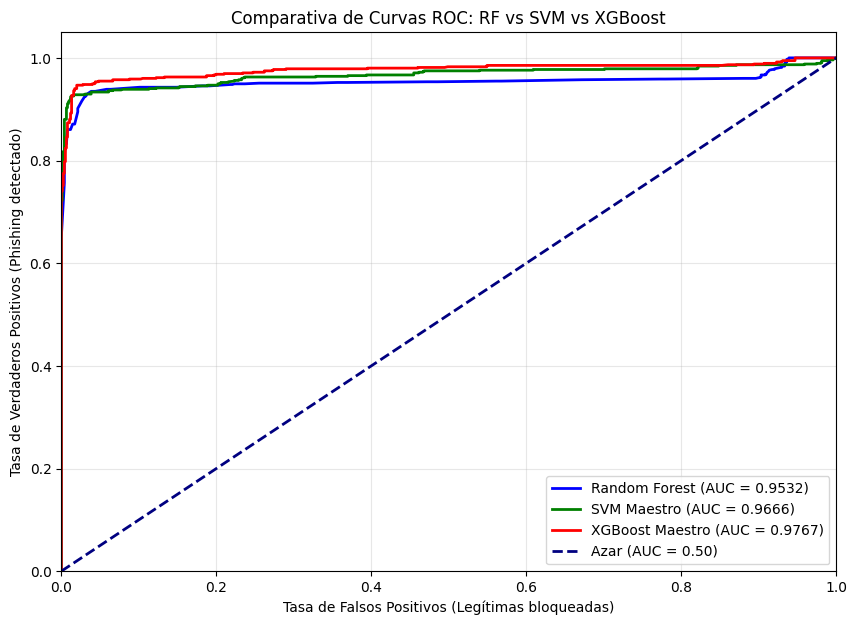

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# 1. Preparación de etiquetas: Phishing (0) pasa a ser la clase positiva (1)
y_roc_phish_is_positive = np.where(y_test_real == 0, 1, 0)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_roc_phish_is_positive, 1 - probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# SVM Maestro
fpr_svm, tpr_svm, _ = roc_curve(y_roc_phish_is_positive, 1 - probs_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# XGBoost Maestro
fpr_xgb, tpr_xgb, _ = roc_curve(y_roc_phish_is_positive, 1 - probs_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# 3. Configuración del Gráfico
plt.figure(figsize=(10, 7))

# Dibujar las curvas
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, 
         label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_svm, tpr_svm, color='green', lw=2, 
         label=f'SVM Maestro (AUC = {roc_auc_svm:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, 
         label=f'XGBoost Maestro (AUC = {roc_auc_xgb:.4f})')

# Línea de base (Azar)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.50)')

# Estética y etiquetas 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Legítimas bloqueadas)')
plt.ylabel('Tasa de Verdaderos Positivos (Phishing detectado)')
plt.title('Comparativa de Curvas ROC: RF vs SVM vs XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Mostrar resultados numéricos
print("🏆 RESUMEN DE RENDIMIENTO:")
print("-" * 40)
print(f"🥇 Random Forest: {roc_auc_rf:.4f}")
print(f"🥈 XGBoost Maestro:    {roc_auc_xgb:.4f}")
print(f"🥉 SVM Maestro:        {roc_auc_svm:.4f}")
print("-" * 40)

plt.show()

# 4.2 Análisis de Eficiencia y Latencia Computacional

Este bloque evalúa la viabilidad operativa de cada modelo mediante pruebas de estrés temporal. El objetivo es determinar cuál de las arquitecturas ofrece la mejor respuesta para un despliegue en tiempo real.

### Factores de Evaluación:
* **Comparativa temporal:** Medición del tiempo de procesamiento por URL (ms/URL) a lo largo de 20 repeticiones para obtener una media estadística fiable.
* **Carga de Preprocesamiento:** Se incluye el tiempo de escalado de datos en el caso de SVM, reflejando el coste real de su implementación en sistemas de producción.
* **Estabilidad del Sistema:** El análisis de la desviación estándar (Std) permite identificar la consistencia de cada algoritmo ante cargas de trabajo masivas.

In [34]:
import time
import numpy as np

n_muestras = len(X_test_real)
reps = 20

times_rf = []
times_xgb = []
times_svm = []

print(f"⏱️ Test de eficiencia ({reps} ejecuciones) sobre {n_muestras} URLs...")
print("-" * 60)

for _ in range(reps):
    
    # --- RANDOM FOREST ---
    start = time.time()
    rf_phi_2024.predict(X_test_real)
    end = time.time()
    times_rf.append((end - start) * 1000 / n_muestras)

    # --- XGBOOST ---
    start = time.time()
    xgb_maestro.predict(X_test_real)
    end = time.time()
    times_xgb.append((end - start) * 1000 / n_muestras)

    # --- SVM (incluye escalado) ---
    start = time.time()
    X_scaled = scaler.transform(X_test_real)
    svm_maestro.predict(X_scaled)
    end = time.time()
    times_svm.append((end - start) * 1000 / n_muestras)

# --- RESULTADOS ---
print(f"{'Algoritmo':<20} | {'Media (ms/URL)':<15} | {'Std':<10}")
print("-" * 60)

print(f"{'Random Forest':<20} | {np.mean(times_rf):<15.6f} | {np.std(times_rf):<10.6f}")
print(f"{'XGBoost':<20} | {np.mean(times_xgb):<15.6f} | {np.std(times_xgb):<10.6f}")
print(f"{'SVM':<20} | {np.mean(times_svm):<15.6f} | {np.std(times_svm):<10.6f}")

print("-" * 60)
print("✅ Test completado")

⏱️ Test de eficiencia (20 ejecuciones) sobre 1504 URLs...
------------------------------------------------------------
Algoritmo            | Media (ms/URL)  | Std       
------------------------------------------------------------
Random Forest        | 0.008524        | 0.001496  
XGBoost              | 0.001282        | 0.000102  
SVM                  | 0.319757        | 0.005214  
------------------------------------------------------------
✅ Test completado
